<a href="https://colab.research.google.com/github/DAN85851/Paca_Digestora_iot/blob/main/entrenamiento_paca_digestora(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificador de Estado de Paca Digestora (Termofílico / Mesofílico / Enfriamiento)

**Objetivo:** entrenar una red neuronal pequeña que, a partir de las lecturas
de temperatura/humedad, prediga en qué fase biológica está la paca digestora.

**Flujo de este notebook:**
1. Cargar y explorar los datos
2. Etiquetar el estado (no viene en el CSV — se deriva con reglas de dominio)
3. Preparar features y hacer un split **cronológico** (no aleatorio, porque son series de tiempo)
4. Barrer varias arquitecturas (distinto número de neuronas ocultas) y comparar cuál generaliza mejor
5. Evaluar el mejor modelo (matriz de confusión, reporte de clasificación)
6. Exportar los pesos para correr inferencia en **numpy puro** en la BeagleBone Black (sin TensorFlow ahí)

> Sube tu CSV a Colab (ícono de carpeta a la izquierda → Subir) y ajusta `CSV_PATH` abajo.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 1. Cargar y explorar los datos

In [ ]:
CSV_PATH = "dataset_paca_30_dias_organico.csv"  # <-- ajusta el nombre/ruta de tu archivo subido

# Leer en BINARIO y limpiar bytes nulos ANTES de que pandas toque el texto
# (la BBB tuvo brownouts durante el logueo -- ver debugging previo -- y eso
# corrompio algunas filas del CSV con bytes nulos mezclados en los datos)
import io

with open(CSV_PATH, "rb") as f:
    bytes_crudos = f.read()

bytes_limpios = bytes_crudos.replace(b"\x00", b"")
texto_limpio = bytes_limpios.decode("utf-8", errors="replace")

df_crudo = pd.read_csv(io.StringIO(texto_limpio), sep=",")
df_crudo.columns = [c.strip() for c in df_crudo.columns]
n_original = len(df_crudo)

df = df_crudo.copy()

# 1) Quitar espacios residuales de las columnas de texto
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

# 2) Forzar columnas numericas; lo que no se pueda convertir se vuelve NaN
columnas_numericas = [
    "Timestamp_Unix", "Temp_Sonda_C", "Hum_Tierra_Pct", "Temp_Amb_C", "Hum_Amb_Pct",
    "Raw_Sonda", "Raw_Tierra", "Raw_AmbT", "Raw_AmbH", "Paquete_Num",
]
for col in columnas_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 3) Descartar filas corruptas (cualquier NaN en columnas clave)
filas_antes = len(df)
df = df.dropna(subset=["Timestamp_Unix", "Temp_Sonda_C", "Hum_Tierra_Pct", "ID_Nodo"])
filas_descartadas = filas_antes - len(df)

print(f"Filas originales   : {n_original}")
print(f"Filas corruptas descartadas: {filas_descartadas} ({filas_descartadas/n_original:.1%})")
print(f"Filas limpias       : {len(df)}")

# Reconstruir Fecha_Hora desde el timestamp ya limpio (numerico de verdad)
df["Fecha_Hora"] = pd.to_datetime(df["Timestamp_Unix"], unit="s")
df["ID_Nodo"] = df["ID_Nodo"].astype(int)
df = df.sort_values(["ID_Nodo", "Timestamp_Unix"]).reset_index(drop=True)

print(f"Nodos: {df['ID_Nodo'].unique()}")
print(f"Rango de fechas: {df['Fecha_Hora'].min()} -> {df['Fecha_Hora'].max()}")
df.head()

Filas originales   : 8640
Filas corruptas descartadas: 0 (0.0%)
Filas limpias       : 8640
Nodos: [1]
Rango de fechas: 2026-05-09 23:33:28 -> 2026-06-08 23:28:28


,Timestamp_Unix,Fecha_Hora,ID_Nodo,Temp_Sonda_C,Hum_Tierra_Pct,Temp_Amb_C,Hum_Amb_Pct,Raw_Sonda,Raw_Tierra,Raw_AmbT,Raw_AmbH,Paquete_Num
0,1778369608,2026-05-09 23:33:28,1,20.87,77.40,19.00,29.56,322,721,453,330,1
1,1778369908,2026-05-09 23:38:28,1,20.89,77.80,18.17,29.01,319,718,444,322,2
2,1778370208,2026-05-09 23:43:28,1,20.90,83.34,18.75,31.92,317,767,453,340,3
3,1778370508,2026-05-09 23:48:28,1,20.90,77.80,18.35,29.77,317,720,447,329,4
4,1778370808,2026-05-09 23:53:28,1,20.89,78.20,17.89,31.24,317,726,442,339,5


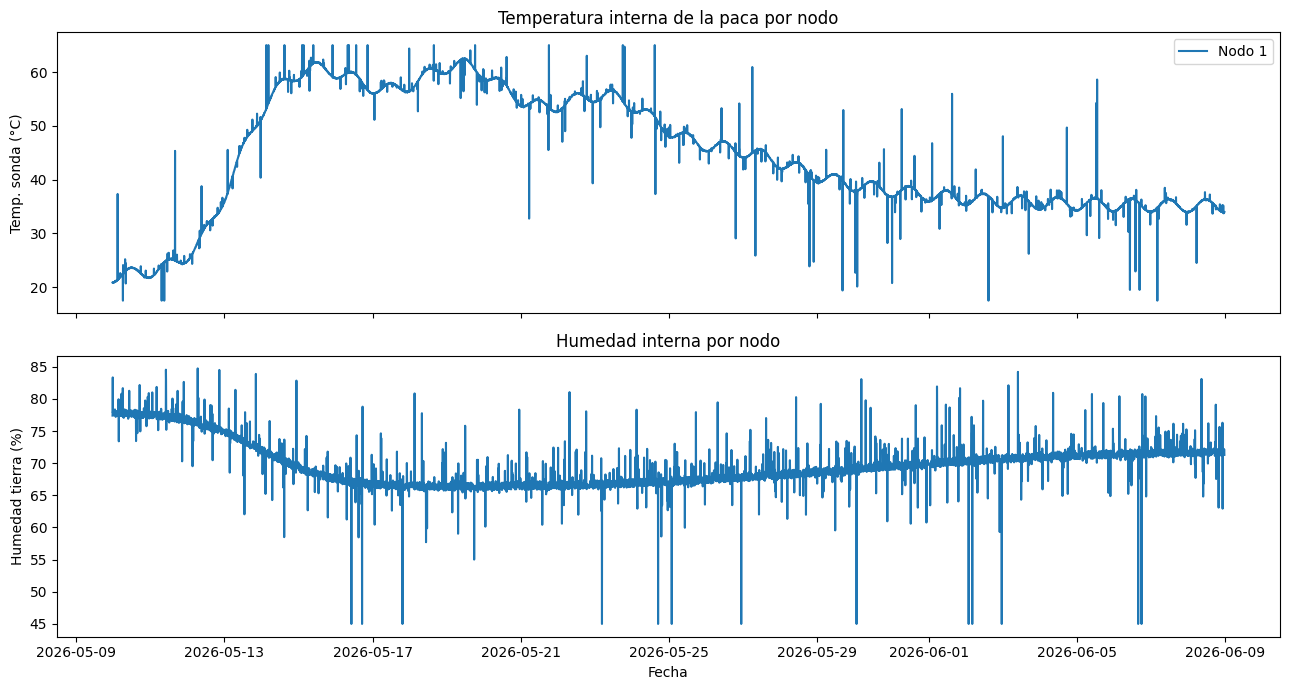

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for nodo, grupo in df.groupby("ID_Nodo"):
    axes[0].plot(grupo["Fecha_Hora"], grupo["Temp_Sonda_C"], label=f"Nodo {nodo}")
    axes[1].plot(grupo["Fecha_Hora"], grupo["Hum_Tierra_Pct"], label=f"Nodo {nodo}")

axes[0].set_ylabel("Temp. sonda (°C)")
axes[0].legend()
axes[0].set_title("Temperatura interna de la paca por nodo")

axes[1].set_ylabel("Humedad tierra (%)")
axes[1].set_xlabel("Fecha")
axes[1].set_title("Humedad interna por nodo")

plt.tight_layout()
plt.show()


## 2. Etiquetar el estado biológico

Tu CSV **no trae la etiqueta** de estado, así que la derivamos con reglas de
dominio basadas en literatura de compostaje/biodigestión:

- **Termofílico**: temperatura interna alta (> 45°C aprox.), fase de mayor
  actividad microbiana.
- **Mesofílico**: temperatura moderada (20–45°C), sin tendencia clara de
  enfriamiento sostenido.
- **Enfriamiento**: temperatura en descenso sostenido después de haber estado
  en fase termofílica (fase de maduración).

La clave para distinguir "Mesofílico" de "Enfriamiento" no es solo el valor
de temperatura sino la **tendencia** (tasa de cambio) — por eso calculamos
una pendiente móvil.




In [ ]:
TEMP_TERMOFILICO = 45.0      # °C, encima de esto se considera termofilico
VENTANA_PENDIENTE = 6        # numero de lecturas para calcular la tendencia (ajusta segun tu frecuencia de muestreo)
PENDIENTE_ENFRIAMIENTO = -0.05  # °C por lectura; mas negativo que esto = enfriando

# Pendiente movil de temperatura, calculada POR NODO (con transform no se
# pierde la columna ID_Nodo, a diferencia de groupby().apply() en pandas
# recientes que excluye la columna de agrupacion del resultado)
df["pendiente_temp"] = (
    df.groupby("ID_Nodo")["Temp_Sonda_C"]
      .transform(lambda s: s.diff().rolling(VENTANA_PENDIENTE, min_periods=2).mean())
)

def estado(row):
    if pd.isna(row["pendiente_temp"]):
        return "Mesofilico"
    if row["Temp_Sonda_C"] >= TEMP_TERMOFILICO:
        return "Termofilico"
    if row["pendiente_temp"] <= PENDIENTE_ENFRIAMIENTO and row["Temp_Sonda_C"] < TEMP_TERMOFILICO:
        return "Enfriamiento"
    return "Mesofilico"

df["Estado"] = df.apply(estado, axis=1)

print(df["Estado"].value_counts())
print()
print(df["Estado"].value_counts(normalize=True).round(3))

Estado
Mesofilico      4425
Termofilico     3965
Enfriamiento     250
Name: count, dtype: int64

Estado
Mesofilico      0.512
Termofilico     0.459
Enfriamiento    0.029
Name: proportion, dtype: float64


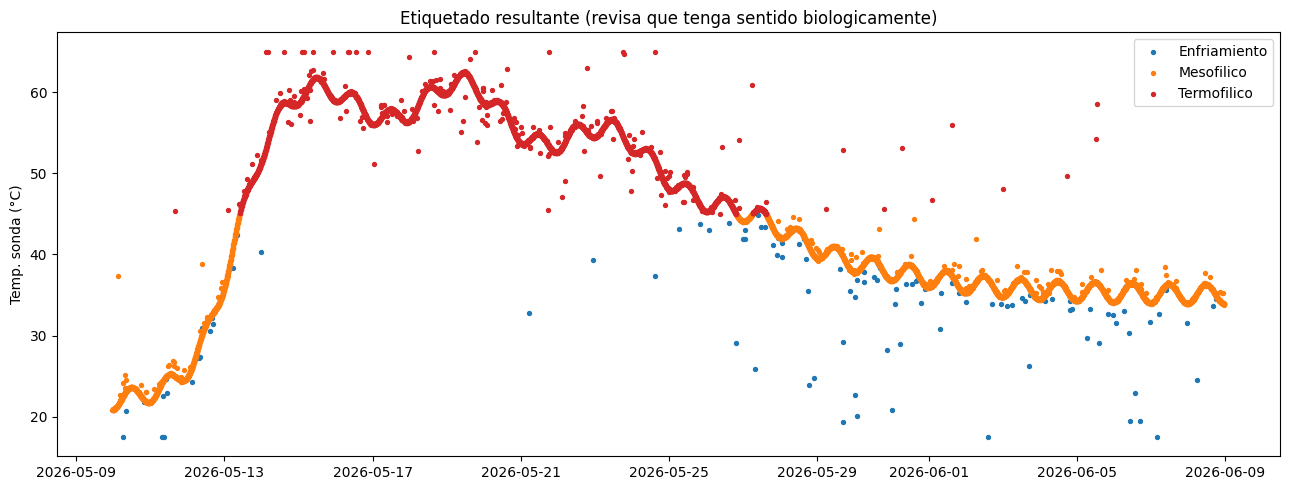

In [ ]:
# Revision visual: colorea la serie de temperatura segun el estado etiquetado
colores = {"Termofilico": "tab:red", "Mesofilico": "tab:orange", "Enfriamiento": "tab:blue"}

fig, ax = plt.subplots(figsize=(13, 5))
for nodo, grupo in df.groupby("ID_Nodo"):
    for estado, sub in grupo.groupby("Estado"):
        ax.scatter(sub["Fecha_Hora"], sub["Temp_Sonda_C"], s=8, color=colores[estado], label=estado)

# leyenda sin duplicados
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
ax.set_ylabel("Temp. sonda (°C)")
ax.set_title("Etiquetado resultante (revisa que tenga sentido biologicamente)")
plt.tight_layout()
plt.show()


In [ ]:
FEATURES = ["Temp_Sonda_C", "Hum_Tierra_Pct", "Temp_Amb_C", "Hum_Amb_Pct", "pendiente_temp"]
CLASES = ["Mesofilico", "Termofilico", "Enfriamiento"]

df_modelo = df.dropna(subset=FEATURES).reset_index(drop=True)

X = df_modelo[FEATURES].values.astype("float32")
y_texto = df_modelo["Estado"].values
y = np.array([CLASES.index(v) for v in y_texto])

# Split por bloques de tiempo entrelazados (ver explicacion arriba).
# Bloques de TAM_BLOQUE lecturas consecutivas; 1 de cada 5 bloques va a test.
TAM_BLOQUE = 5
n = len(X)
bloque_id = np.arange(n) // TAM_BLOQUE
es_test = (bloque_id % 5 == 0)

X_train, X_test = X[~es_test], X[es_test]
y_train, y_test = y[~es_test], y[es_test]

# normalizacion: media/std SOLO del set de entrenamiento (evita fuga de datos)
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0) + 1e-8

X_train_n = (X_train - mu) / sigma
X_test_n  = (X_test  - mu) / sigma

print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(f"Distribucion train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Distribucion test : {dict(zip(*np.unique(y_test, return_counts=True)))}")
print(f"Clases -> indices: {dict(enumerate(CLASES))}")


Train: (6908, 5)  Test: (1730, 5)
Distribucion train: {np.int64(0): np.int64(3527), np.int64(1): np.int64(3175), np.int64(2): np.int64(206)}
Distribucion test : {np.int64(0): np.int64(896), np.int64(1): np.int64(790), np.int64(2): np.int64(44)}
Clases -> indices: {0: 'Mesofilico', 1: 'Termofilico', 2: 'Enfriamiento'}


## 4. Barrido de arquitecturas

Probamos varias configuraciones (distinto número de neuronas en la capa
oculta) y comparamos qué tan bien detectan **las 3 clases**, no solo el
accuracy global.

Si el accuracy simple diera 95%+ pero la red nunca predijera "Termofílico"
ni una sola vez, ese accuracy sería una ilusión — el modelo solo estaría
aprendiendo a decir siempre la clase mayoritaria. Por eso:

- Usamos **class weights** al entrenar, para que la red le preste más
  atención a las clases minoritarias (Termofílico, Enfriamiento).
- Comparamos arquitecturas con **F1-macro** (promedio del F1 de cada clase
  por igual, sin favorecer a la mayoritaria), no solo con accuracy.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, balanced_accuracy_score

CONFIGURACIONES = [4, 8, 16, 32, 64]  # numero de neuronas en la capa oculta
EPOCAS = 60

# Pesos de clase: las clases minoritarias (Termofilico, Enfriamiento) pesan
# mas en la funcion de perdida, para que la red no las ignore
clases_presentes = np.unique(y_train)
pesos = compute_class_weight("balanced", classes=clases_presentes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(clases_presentes, pesos)}
print("Class weights:", {CLASES[c]: round(w, 2) for c, w in class_weight.items()})
print()

resultados = []
modelos = {}

for n_neuronas in CONFIGURACIONES:
    modelo = keras.Sequential([
        keras.layers.Input(shape=(len(FEATURES),)),
        keras.layers.Dense(n_neuronas, activation="relu"),
        keras.layers.Dense(len(CLASES), activation="softmax"),
    ])
    modelo.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    historia = modelo.fit(
        X_train_n, y_train,
        validation_data=(X_test_n, y_test),
        epochs=EPOCAS, batch_size=32, verbose=0,
        class_weight=class_weight,
    )

    y_pred_val = np.argmax(modelo.predict(X_test_n, verbose=0), axis=1)
    val_acc = historia.history["val_accuracy"][-1]
    f1_macro = f1_score(y_test, y_pred_val, labels=list(range(len(CLASES))), average="macro", zero_division=0)
    bal_acc = balanced_accuracy_score(y_test, y_pred_val)
    n_params = modelo.count_params()

    resultados.append({
        "neuronas_ocultas": n_neuronas,
        "val_accuracy": val_acc,
        "f1_macro": f1_macro,
        "balanced_accuracy": bal_acc,
        "parametros": n_params,
    })
    modelos[n_neuronas] = (modelo, historia)

    print(f"Neuronas={n_neuronas:>3} | val_acc={val_acc:.3f} | f1_macro={f1_macro:.3f} | "
          f"balanced_acc={bal_acc:.3f} | params={n_params}")

tabla_resultados = pd.DataFrame(resultados)
tabla_resultados

Class weights: {'Mesofilico': 0.65, 'Termofilico': 0.73, 'Enfriamiento': 11.18}

Neuronas=  4 | val_acc=0.991 | f1_macro=0.971 | balanced_acc=0.994 | params=39
Neuronas=  8 | val_acc=0.992 | f1_macro=0.968 | balanced_acc=0.995 | params=75
Neuronas= 16 | val_acc=0.990 | f1_macro=0.961 | balanced_acc=0.994 | params=147
Neuronas= 32 | val_acc=0.991 | f1_macro=0.959 | balanced_acc=0.994 | params=291
Neuronas= 64 | val_acc=0.991 | f1_macro=0.962 | balanced_acc=0.994 | params=579


,neuronas_ocultas,val_accuracy,f1_macro,balanced_accuracy,parametros
0,4,0.990751,0.970527,0.993898,39
1,8,0.991908,0.968314,0.994742,75
2,16,0.990173,0.961302,0.993626,147
3,32,0.990751,0.958887,0.993998,291
4,64,0.991329,0.962121,0.994420,579


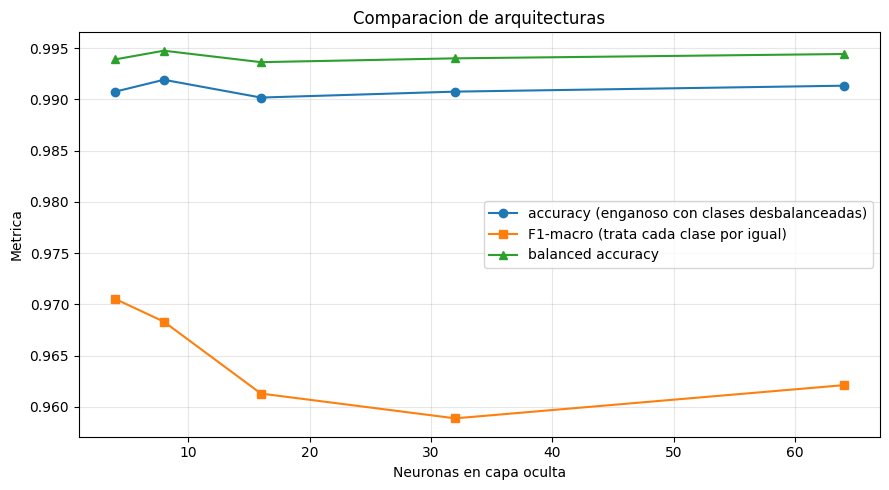

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tabla_resultados["neuronas_ocultas"], tabla_resultados["val_accuracy"],
        marker="o", label="accuracy (enganoso con clases desbalanceadas)")
ax.plot(tabla_resultados["neuronas_ocultas"], tabla_resultados["f1_macro"],
        marker="s", label="F1-macro (trata cada clase por igual)")
ax.plot(tabla_resultados["neuronas_ocultas"], tabla_resultados["balanced_accuracy"],
        marker="^", label="balanced accuracy")
ax.set_xlabel("Neuronas en capa oculta")
ax.set_ylabel("Metrica")
ax.set_title("Comparacion de arquitecturas")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Cómo elegir la mejor:** no te quedes solo con el número más alto de
accuracy — si dos configuraciones dan resultados parecidos, prefiere la que
tenga **menos neuronas** (menos parámetros = menos riesgo de sobreajuste, y
más rápida/liviana para correr luego en la BBB). Ajusta la variable
`MEJOR_N_NEURONAS` abajo según lo que veas en tu gráfica.


In [ ]:
# Elegimos por F1-macro, NO por accuracy simple -- con este desbalance de
# clases, el accuracy premia a un modelo que solo predice la clase mayoritaria
MEJOR_N_NEURONAS = int(tabla_resultados.loc[tabla_resultados["f1_macro"].idxmax(), "neuronas_ocultas"])
print(f"Arquitectura elegida: {MEJOR_N_NEURONAS} neuronas ocultas (mejor F1-macro)")

mejor_modelo, mejor_historia = modelos[MEJOR_N_NEURONAS]

Arquitectura elegida: 4 neuronas ocultas (mejor F1-macro)


## 5. Evaluación del mejor modelo

              precision    recall  f1-score   support

  Mesofilico       1.00      0.99      0.99       896
 Termofilico       0.99      1.00      0.99       790
Enfriamiento       0.86      1.00      0.93        44

    accuracy                           0.99      1730
   macro avg       0.95      0.99      0.97      1730
weighted avg       0.99      0.99      0.99      1730



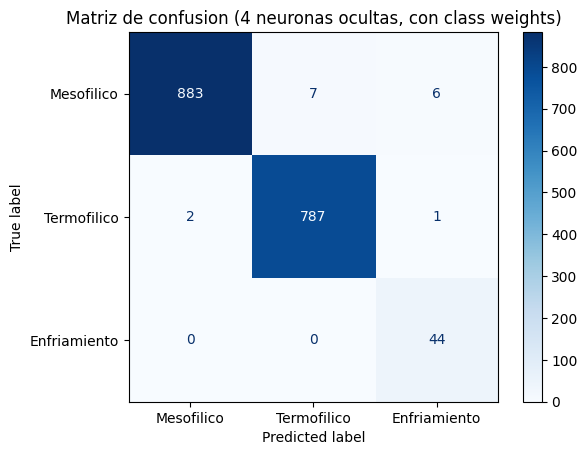

In [ ]:
y_pred = np.argmax(mejor_modelo.predict(X_test_n, verbose=0), axis=1)

print(classification_report(
    y_test, y_pred,
    labels=list(range(len(CLASES))), target_names=CLASES, zero_division=0,
))

cm = confusion_matrix(y_test, y_pred, labels=list(range(len(CLASES))))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASES)
disp.plot(cmap="Blues")
plt.title(f"Matriz de confusion ({MEJOR_N_NEURONAS} neuronas ocultas, con class weights)")
plt.show()

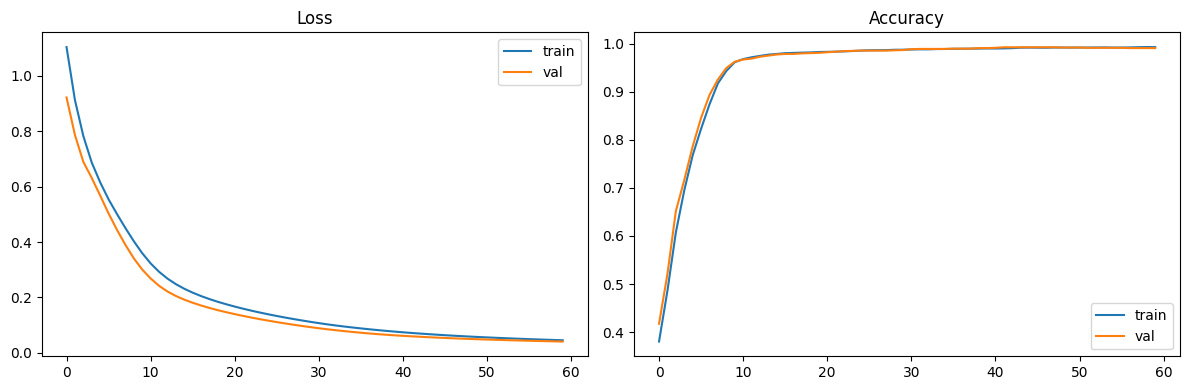

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mejor_historia.history["loss"], label="train")
axes[0].plot(mejor_historia.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(mejor_historia.history["accuracy"], label="train")
axes[1].plot(mejor_historia.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Exportar para inferencia en numpy puro (BeagleBone Black)



In [ ]:
pesos = mejor_modelo.get_weights()
W1, b1, W2, b2 = pesos  # Dense1: W1,b1 | Dense2 (salida): W2,b2

np.savez(
    "modelo_paca_pesos.npz",
    W1=W1, b1=b1, W2=W2, b2=b2,
    mu=mu, sigma=sigma,
    features=np.array(FEATURES),
    clases=np.array(CLASES),
)

print("Guardado: modelo_paca_pesos.npz")
print(f"W1: {W1.shape}  b1: {b1.shape}  W2: {W2.shape}  b2: {b2.shape}")


Guardado: modelo_paca_pesos.npz
W1: (5, 4)  b1: (4,)  W2: (4, 3)  b2: (3,)


In [ ]:
# --- Reimplementacion en numpy puro (esto es lo que se copia a fb_dashboard.py / lora_parser.py en la BBB) ---

def relu(x):
    return np.maximum(0, x)

def softmax(x):
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

def predecir_numpy(x_crudo, W1, b1, W2, b2, mu, sigma, clases):
    x_norm = (np.asarray(x_crudo, dtype="float32") - mu) / sigma
    h = relu(x_norm @ W1 + b1)
    salida = softmax(h @ W2 + b2)
    idx = int(np.argmax(salida))
    return clases[idx], salida

# --- Verificacion: la salida de numpy debe coincidir con la de TensorFlow ---
i = 0  # cambia el indice para probar con otras muestras del set de test
x_prueba = X_test[i]

clase_tf = CLASES[int(np.argmax(mejor_modelo.predict(X_test_n[i:i+1], verbose=0)))]
clase_np, probs_np = predecir_numpy(x_prueba, W1, b1, W2, b2, mu, sigma, CLASES)

print(f"Prediccion TensorFlow : {clase_tf}")
print(f"Prediccion numpy puro : {clase_np}")
print(f"Probabilidades (numpy): {dict(zip(CLASES, np.round(probs_np, 3)))}")
assert clase_tf == clase_np, "Las predicciones no coinciden -- revisa la normalizacion"
print("\n✅ Las dos implementaciones coinciden.")


Prediccion TensorFlow : Mesofilico
Prediccion numpy puro : Mesofilico
Probabilidades (numpy): {'Mesofilico': np.float32(0.997), 'Termofilico': np.float32(0.0), 'Enfriamiento': np.float32(0.003)}

✅ Las dos implementaciones coinciden.


## Siguientes pasos

1. Descarga `modelo_paca_pesos.npz` (panel de archivos a la izquierda en Colab) y súbelo a la BBB.
2. En la BBB, carga el `.npz` con `np.load(...)` y usa la función `predecir_numpy` de arriba dentro de tu `lora_parser.py` cada vez que llegue una nueva lectura.
3. Guarda las lecturas + la predicción del día en la SD (con rotación, para no desgastarla) para poder reentrenar periódicamente repitiendo este mismo notebook con datos nuevos.
4. Cuando tengas más datos etiquetados con confianza (o etiquetados manualmente en vez de por reglas), puedes volver a este notebook, reentrenar, y reemplazar el `.npz` en la BBB.
